# 14_gap_interpolation_check_JIW

- 목적: burst 사이 **측정되지 않은 공백을 보간해서 연속 신호로 모델에 넘겨도 되는가**를 값이 있는 구간을 가려서 검증한다. 설계: `docs/final_design_JIW.md` §2.1~2.2.
- 입력: `data/raw`(→ 표준 전처리 `preprocess.preprocess()`), `data/processed/segments.csv`(burst 시작 시각). **모델 학습 없음.**
- 출력: `figures/14_gap_interpolation_check_JIW/`, `results/14_gap_interpolation_check_JIW/`(gaps.csv · mask_eval.csv · holdout_summary.csv · burst_frequencies.csv · phase_continuity.csv · verdict.csv)
- 담당: JIW
- 심사 대응: 1번(결측·공백 처리의 타당성), 5번(도메인 신호 기반 판단)
- 근거 표기: **[데이터]** 이 노트북 출력 / **[추정]** 미검증

## 검증 설계

공백 구간의 실제 값은 없으므로 **값이 있는 구간을 가려** 보간이 복원하는지 잰다. 판정은 가린 구간의 채널별 합산 R²(분산 설명 비율) ≥ 0.9다. 입력은 세그먼트 평균이 제거된 표준 전처리 결과다.

| 검증 | 방법 | 묻는 것 |
|---|---|---|
| A. burst 안 마스킹 | 정상 burst 가운데 k샘플(0.5~3초)을 가리고 0 채움·선형·3차 스플라인·사인 피팅으로 복원 | 짧은 공백은 메울 수 있나 |
| B. 실제 공백 홀드아웃 | 연속한 세 정상 burst 중 **가운데 burst를 통째로 가리고** 앞뒤 burst(실제 공백 2개 포함)로 복원 | 실제 공백을 건너 복원할 수 있나 |
| C. 위상 연속성 | 앞 burst의 전류 사인을 공백 너머로 이어 다음 burst와 위상을 비교 | 전류 파형이 burst를 건너 이어지나 |

사인 모델은 burst마다 오프셋을 따로 둔다(평균이 burst마다 제거돼 DC가 이어지지 않으므로). 파형의 진폭·주파수·위상 연속성만 본다.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
import paths
NB = "14_gap_interpolation_check_JIW"  # 파일명(확장자 제외)과 같게
FIG, RES = paths.nb_dirs(NB)
SEED = 42
np.random.seed(SEED)
import gap_interp_jiw as G
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)
segs, S = G.load_normal()
print(NB, "정상 burst", len(segs), " 길이 ≥ 40 샘플", int((S["len"] >= 40).sum()), " 길이 중앙값", int(S["len"].median()))

14_gap_interpolation_check_JIW 정상 burst 599  길이 ≥ 40 샘플 276  길이 중앙값 37


## 1. 실제 공백은 얼마나 긴가

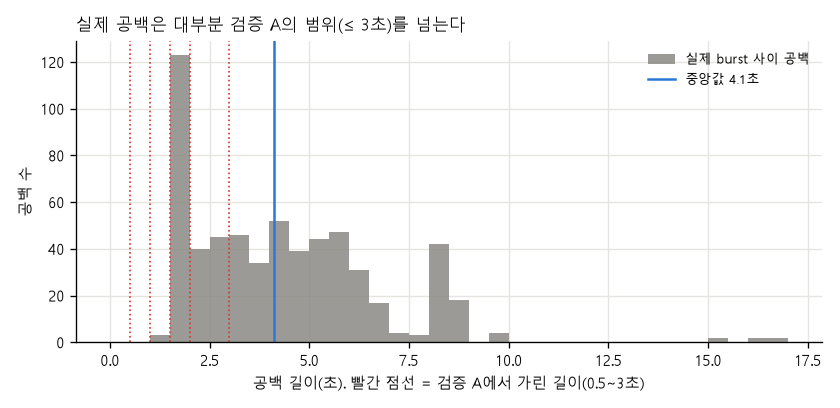

,공백(초)
count,598.000
mean,4.370
std,2.450
min,1.450
5%,1.630
25%,2.310
50%,4.120
75%,5.710
95%,8.460
max,16.540


In [2]:
gaps = G.real_gaps(S)
gt = pd.DataFrame({"공백(초)": gaps.describe(percentiles=[.05, .25, .5, .75, .95]).round(2)})
gt.loc["≤ 2초 비율"] = round(float((gaps <= 2.0).mean()), 3)
gt.loc["≤ 3초 비율"] = round(float((gaps <= 3.0).mean()), 3)
gt.to_csv(RES / "gaps.csv")
G.plot_gap_hist(gaps, [5, 10, 15, 20, 30], FIG); display(Image(FIG / "gap_hist.png"))
gt

**발견 [데이터]** 공백은 중앙값 **4.1초(약 41샘플)**, 5~95% 구간 1.6~8.5초, 최대 16.5초다. burst 길이(중앙값 3.7초, 최대 5초)와 비슷하거나 더 길다. 검증 A에서 가리는 길이(0.5~3초) 안에 드는 공백은 35%(≤ 3초)뿐이고 2초 이하는 21%다.

## 2. 검증 A — burst 안 마스킹

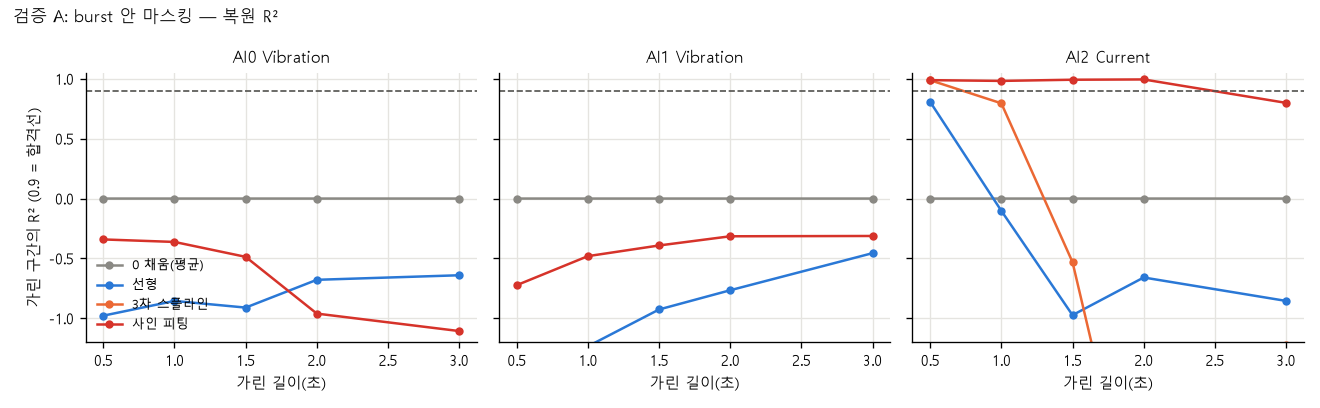

초                      0.5    1.0    1.5    2.0     3.0
채널            방법                                       
AI0_Vibration cubic  -7.07 -13.02 -14.10 -25.62 -110.80
              linear -0.98  -0.85  -0.91  -0.68   -0.64
              sine   -0.34  -0.36  -0.49  -0.96   -1.11
              zero   -0.00  -0.00  -0.00  -0.00   -0.00
AI1_Vibration cubic  -4.05  -5.90  -5.09 -10.89  -55.75
              linear -1.23  -1.23  -0.93  -0.77   -0.46
              sine   -0.72  -0.48  -0.39  -0.32   -0.31
              zero   -0.00  -0.00  -0.00  -0.00   -0.00
AI2_Current   cubic   0.99   0.80  -0.53  -3.05   -1.22
              linear  0.81  -0.10  -0.97  -0.66   -0.85
              sine    0.99   0.98   0.99   0.99    0.80
              zero   -0.00  -0.00  -0.00  -0.00   -0.00

nRMSE (복원 오차 / 채널 표준편차, 1 = 0 채움과 같은 수준)


초                      0.5   1.0   1.5   2.0    3.0
채널            방법                                   
AI0_Vibration cubic   2.84  3.74  3.89  5.16  10.57
              linear  1.41  1.36  1.38  1.30   1.28
              sine    1.16  1.17  1.22  1.40   1.45
              zero    1.00  1.00  1.00  1.00   1.00
AI1_Vibration cubic   2.25  2.63  2.47  3.45   7.53
              linear  1.49  1.49  1.39  1.33   1.21
              sine    1.31  1.22  1.18  1.15   1.15
              zero    1.00  1.00  1.00  1.00   1.00
AI2_Current   cubic   0.11  0.45  1.24  2.01   1.49
              linear  0.44  1.05  1.40  1.29   1.36
              sine    0.11  0.13  0.09  0.07   0.45
              zero    1.00  1.00  1.00  1.00   1.00

In [3]:
me = G.mask_eval(segs)
me.to_csv(RES / "mask_eval.csv", index=False)
G.plot_mask_r2(me, FIG); display(Image(FIG / "mask_r2.png"))
display(me.pivot_table(index=["채널", "방법"], columns="초", values="R2").round(2))
print("nRMSE (복원 오차 / 채널 표준편차, 1 = 0 채움과 같은 수준)")
me.pivot_table(index=["채널", "방법"], columns="초", values="nRMSE").round(2)

**발견 [데이터]**
- **진동(AI0·AI1)은 어떤 방법도 안 된다.** R²가 0 채움(= 0)보다 낮거나 음수이고, 3차 스플라인은 가릴수록 크게 나빠진다(3초에서 −55~−111). 진동은 평균 0 주변의 불규칙 신호라 앞뒤 값으로 가운데를 예측할 수 없다 — **0 채움이 가장 덜 해롭다.**
- **전류(AI2)는 사인 피팅만 된다.** R² 0.99(0.5~2초), 3초에서 0.80으로 합격선(0.9)을 넘는 한계는 **2초(20샘플)**다. 선형은 0.5초에서만 0.81, 3차 스플라인은 1초에서 이미 0.80이다. 전류는 0.6 Hz로 접힌 규칙적 사인(R² 0.996)이라 같은 burst 안에서는 메울 수 있다.

## 3. 검증 B — 실제 공백 홀드아웃

연속한 세 정상 burst의 가운데를 통째로 가리고 앞뒤 burst(공백 2개, 합계 span 8~16초)로 복원한다. 선형은 평균이 burst마다 제거돼 끝값이 이어지지 않으므로 끝점 선형을 비교용으로 둔다.

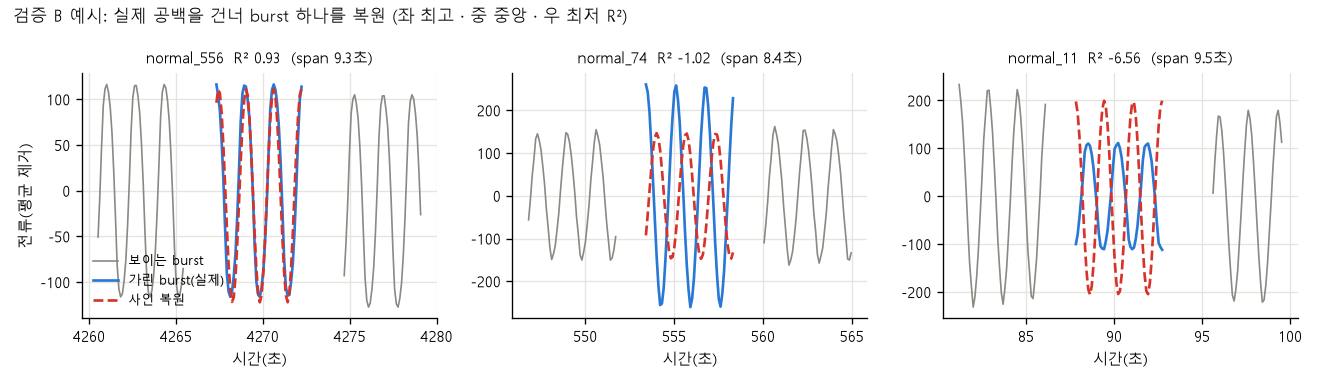

구간                    [8, 12)  [12, 16)
채널            방법                       
AI0_Vibration linear    -0.05     -0.01
              sine      -0.07     -0.10
              zero       0.00      0.00
AI1_Vibration linear    -0.04     -0.02
              sine      -0.02     -0.03
              zero       0.00      0.00
AI2_Current   linear    -0.04     -0.01
              sine      -0.98     -0.61
              zero      -0.00      0.00

In [4]:
h = G.holdout_eval(segs, S)
hs = G.holdout_summary(h)
hs.to_csv(RES / "holdout_summary.csv", index=False)
G.plot_holdout_example(segs, S, FIG); display(Image(FIG / "holdout_example.png"))
hs.pivot_table(index=["채널", "방법"], columns="구간", values="R2", observed=True).round(2)

In [5]:
print("가린 burst 수:", hs.groupby("구간", observed=True)["burst"].max().to_dict())
tot = h.groupby(["채널", "방법"]).agg(sse=("sse", "sum"), sst=("sst", "sum"))
(1 - tot["sse"] / tot["sst"]).round(2).rename("전체 R²").to_frame()

가린 burst 수: {Interval(8, 12, closed='left'): 241, Interval(12, 16, closed='left'): 18}


전체 R²
채널            방법           
AI0_Vibration linear  -0.04
              sine    -0.07
              zero     0.00
AI1_Vibration linear  -0.04
              sine    -0.02
              zero     0.00
AI2_Current   linear  -0.04
              sine    -0.96
              zero     0.00

**발견 [데이터]** **실제 공백을 건너서는 전류도 복원되지 않는다.** 사인 복원의 R²가 −0.98 / −0.61(span 8~12 / 12~16초)로 **0 채움(R² = 0)보다 나쁘다.** 복원한 파형이 실제와 어긋난 위상으로 놓이기 때문이다. 진동은 모든 방법이 0 근처이거나 음수다.

## 4. 검증 C — 왜 전류가 burst를 건너 이어지지 않나: 위상 연속성

burst 안: 주파수 평균 0.5999 Hz, 표준편차 0.0017 Hz, 사인 R² 중앙값 0.9963 (길이 ≥ 40 burst 276개)
burst 사이: 연속 burst 쌍 179개, |위상 오차| 중앙값 1.60 rad (무작위 위상이면 π/2 = 1.57)
위상 오차의 합성 길이 R = 0.040 (0이면 균등), Rayleigh 검정 p ≈ 0.75, 앞 burst의 사인으로 다음 burst 예측 R² 중앙값 -1.28, R² > 0.9인 쌍 5.0%
공백 ≤ 2.5초인 쌍: 139 개, |위상 오차| 중앙값 1.53 rad


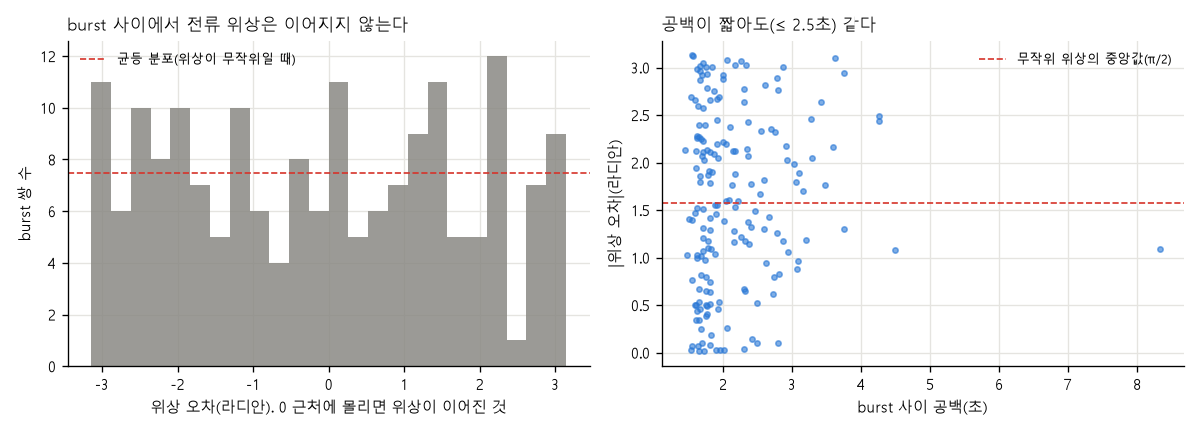

In [6]:
bf = G.burst_frequencies(segs, S)
bf.to_csv(RES / "burst_frequencies.csv", index=False)
pc = G.phase_continuity(segs, S)
pc.to_csv(RES / "phase_continuity.csv", index=False)
e = pc["phase_err"].to_numpy(); n = len(e)
R = float(np.hypot(np.cos(e).mean(), np.sin(e).mean()))
print("burst 안: 주파수 평균", round(bf.f_hz.mean(), 4), "Hz, 표준편차", round(bf.f_hz.std(), 4), "Hz, 사인 R² 중앙값", round(bf.r2.median(), 4), f"(길이 ≥ 40 burst {len(bf)}개)")
print(f"burst 사이: 연속 burst 쌍 {n}개, |위상 오차| 중앙값 {np.median(np.abs(e)):.2f} rad (무작위 위상이면 π/2 = 1.57)")
print(f"위상 오차의 합성 길이 R = {R:.3f} (0이면 균등), Rayleigh 검정 p ≈ {np.exp(-n * R ** 2):.2f}, 앞 burst의 사인으로 다음 burst 예측 R² 중앙값 {pc.r2_forward.median():.2f}, R² > 0.9인 쌍 {(pc.r2_forward > 0.9).mean():.1%}")
print("공백 ≤ 2.5초인 쌍:", int((pc.gap_s <= 2.5).sum()), "개, |위상 오차| 중앙값", round(float(np.median(np.abs(e[pc.gap_s <= 2.5]))), 2), "rad")
G.plot_phase(pc, FIG); display(Image(FIG / "phase_continuity.png"))

**발견 [데이터]**
- **burst 안에서 전류는 매우 규칙적이다.** 주파수 0.5999 ± 0.0017 Hz, 사인 R² 0.996. 그래서 검증 A의 사인 복원이 2초까지 되는 것이다.
- **burst 사이에서는 위상이 무작위다.** 위상 오차의 |값| 중앙값이 1.60 rad로 무작위 위상의 기댓값(π/2 = 1.57)과 같고, 합성 길이 R = 0.04, Rayleigh 검정으로 균등 분포를 기각하지 못한다(p ≈ 0.75). 공백이 2.5초 이하여도 같다(중앙값 1.53 rad). 앞 burst의 사인을 이어서 다음 burst를 예측하면 R² 중앙값이 −1.28이고 0.9를 넘는 쌍은 5%뿐이다.
- 주파수가 안정적인데 위상만 무작위라는 것은 **공백 구간의 위상 드리프트 때문이 아니라 burst마다 위상이 새로 정해진다**는 뜻이다. 접힌 60 Hz 성분의 위상이 DAQ가 burst를 새로 시작할 때마다 바뀌는 것으로 추정한다 [추정, 하드웨어 동작은 확인 못 함]. 이 경우 공백이 아무리 짧아도 이어 붙일 수 없다.

## 5. 판정

In [7]:
v = pd.DataFrame([
    {"채널": "진동 AI0·AI1", "burst 안 짧은 공백(≤ 2초)": "불가 (모든 방법 R² ≤ 0, 0 채움이 최선)", "실제 공백(중앙값 4.1초)": "불가", "판정": "보간하지 않는다"},
    {"채널": "전류 AI2", "burst 안 짧은 공백(≤ 2초)": "가능 (사인 피팅 R² 0.98~0.99, 3초 0.80)", "실제 공백(중앙값 4.1초)": "불가 (사인 R² −0.98 / −0.61, burst 사이 위상 무작위)", "판정": "burst 안에서만, 공백은 보간하지 않는다"},
])
v.to_csv(RES / "verdict.csv", index=False)
v

,채널,burst 안 짧은 공백(≤ 2초),실제 공백(중앙값 4.1초),판정
0,진동 AI0·AI1,"불가 (모든 방법 R² ≤ 0, 0 채움이 최선)",불가,보간하지 않는다
1,전류 AI2,"가능 (사인 피팅 R² 0.98~0.99, 3초 0.80)","불가 (사인 R² −0.98 / −0.61, burst 사이 위상 무작위)","burst 안에서만, 공백은 보간하지 않는다"


**결론 [데이터 + 추정]**
1. **공백을 보간해 연속 신호로 만들지 않는다.** 실제 공백(중앙값 4.1초)에서는 진동·전류 모두 복원되지 않고, 잘못 복원한 값은 0 채움보다 나쁘다. 설계서 §2.1의 "공백 보간 불채택"이 수치로 확인됐다.
2. 보간이 가능한 유일한 경우(burst **안**의 전류 2초 이하 결측)는 이 데이터에 필요하지 않다(burst 안에 결측은 없다).
3. 모델 입력은 지금처럼 **burst 안의 윈도우**로만 만들고, burst 간 정보는 burst별 점수의 시간 흐름(33번)으로 쓴다.
4. 전류 위상이 burst마다 새로 정해진다는 점은 **burst를 이어 붙여 만든 시퀀스(가이드북 방식)가 위상 불연속을 포함한다**는 뜻이다. 가이드북이 행을 이어 붙여 20시점 시퀀스를 만든 것은 burst 경계에서 파형이 끊기는 시퀀스를 학습·평가에 섞는다 (29번 G1의 점검 항목).

## 6. 해석

발견 → 시사점 → 활용은 `reports/14_gap_interpolation_check_JIW.md`에 정리했다.